In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/shopee-product-matching/sample_submission.csv
/kaggle/input/competitions/shopee-product-matching/train.csv
/kaggle/input/competitions/shopee-product-matching/test.csv


KeyboardInterrupt: 

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import torch
from sklearn.preprocessing import StandardScaler
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

In [4]:
train = pd.read_csv("/kaggle/input/competitions/shopee-product-matching/train.csv")
test = pd.read_csv("/kaggle/input/competitions/shopee-product-matching/test.csv")

print(train.head())

         posting_id                                 image       image_phash  \
0   train_129225211  0000a68812bc7e98c42888dfb1c07da0.jpg  94974f937d4c2433   
1  train_3386243561  00039780dfc94d01db8676fe789ecd05.jpg  af3f9460c2838f0f   
2  train_2288590299  000a190fdd715a2a36faed16e2c65df7.jpg  b94cb00ed3e50f78   
3  train_2406599165  00117e4fc239b1b641ff08340b429633.jpg  8514fc58eafea283   
4  train_3369186413  00136d1cf4edede0203f32f05f660588.jpg  a6f319f924ad708c   

                                               title  label_group  
0                          Paper Bag Victoria Secret    249114794  
1  Double Tape 3M VHB 12 mm x 4,5 m ORIGINAL / DO...   2937985045  
2        Maling TTS Canned Pork Luncheon Meat 397 gr   2395904891  
3  Daster Batik Lengan pendek - Motif Acak / Camp...   4093212188  
4                  Nescafe \xc3\x89clair Latte 220ml   3648931069  


In [5]:
print(train.info())
print(train["label_group"].nunique())
print(train["image"].nunique())
print(train["title"].nunique())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34250 entries, 0 to 34249
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   posting_id   34250 non-null  object
 1   image        34250 non-null  object
 2   image_phash  34250 non-null  object
 3   title        34250 non-null  object
 4   label_group  34250 non-null  int64 
dtypes: int64(1), object(4)
memory usage: 1.3+ MB
None
11014
32412
33117


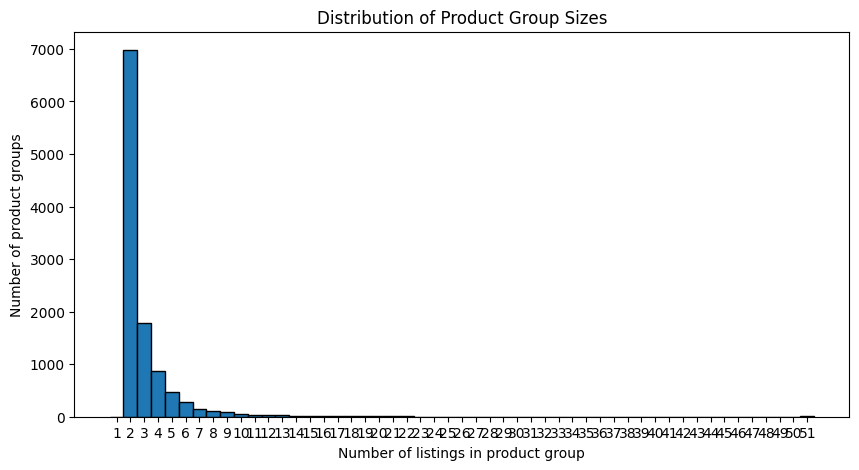

In [7]:
group_sizes = train["label_group"].value_counts()

plt.figure(figsize=(10, 5))

plt.hist(group_sizes, bins=range(1, group_sizes.max() + 2), 
         edgecolor="black", align="left")

plt.xlabel("Number of listings in product group")
plt.ylabel("Number of product groups")
plt.title("Distribution of Product Group Sizes")
plt.xticks(range(1, group_sizes.max() + 1))

plt.show()

### Higly similar product titles

Titles are considered highly similar if they have a cosine similarity of atleast 0.8 .
Cosine similarity is the dot product of two vectors divided by their product of norm  
  
We take fixed amount of nearest neighbors which is by cosine distance and then use cosine similarity on them to find highly similar titles.


In [8]:
from sklearn.neighbors import NearestNeighbors
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(train["title"].fillna(""))

NN = NearestNeighbors(
    n_neighbors=15,
    metric="cosine",
    n_jobs=-1
)

NN.fit(X)

distances, indices = NN.kneighbors(X)

similarities = 1 - distances

count = (similarities[:, 1:] >= 0.8).sum()

pairs = set()

for i in range(len(indices)):
    for j, sim in zip(indices[i, 1:], similarities[i, 1:]):
        if sim >= 0.8:
            pairs.add(tuple(sorted((i, j))))

print("Unique highly similar pairs:", len(pairs))

Unique highly similar pairs: 18544


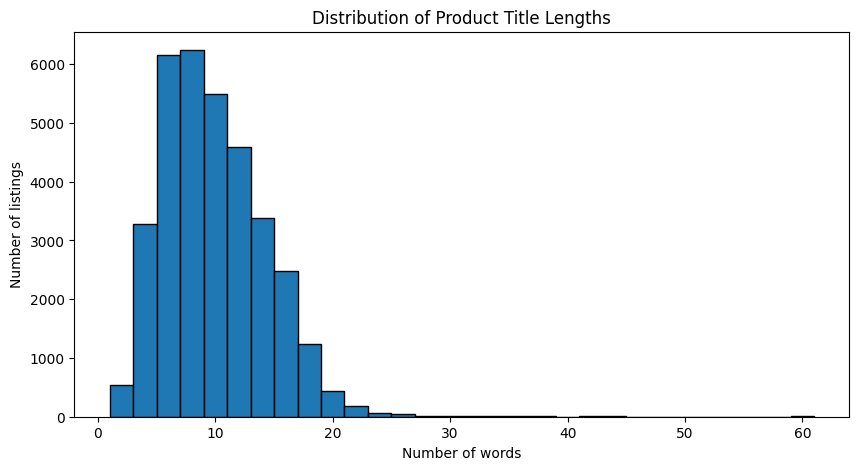

In [9]:
train["title_char_len"] = train["title"].fillna("").str.len()

train["title_word_len"] = train["title"].fillna("").str.split().str.len()

plt.figure(figsize=(10, 5))

plt.hist(
    train["title_word_len"],
    bins=30,
    edgecolor="black"
)

plt.xlabel("Number of words")
plt.ylabel("Number of listings")
plt.title("Distribution of Product Title Lengths")

plt.show()

In [10]:
import os
import numpy as np
import pandas as pd
from PIL import Image
from collections import Counter
import matplotlib.pyplot as plt

DATA_DIR = "/kaggle/input/competitions/shopee-product-matching"
IMG_DIR = os.path.join(DATA_DIR, "train_images")

In [13]:
def get_dominant_color(image_path):
    img = Image.open(image_path).convert("RGB")
    img = img.resize((64, 64))

    pixels = np.array(img).reshape(-1, 3)

    # Average RGB color of the image
    avg_color = pixels.mean(axis=0)

    r, g, b = avg_color

    if max(avg_color) < 50:
        return "black"
    elif min(avg_color) > 200:
        return "white"
    elif max(avg_color) - min(avg_color) < 30:
        return "gray"
    elif r > g * 1.3 and r > b * 1.3:
        return "red"
    elif g > r * 1.2 and g > b * 1.2:
        return "green"
    elif b > r * 1.2 and b > g * 1.2:
        return "blue"
    elif r > 150 and g > 100 and b < 100:
        return "yellow/orange"
    elif r > b * 1.2 and g > b * 1.2:
        return "yellow"
    elif r > g * 1.1 and b > g * 1.1:
        return "pink/purple"
    else:
        return "other"

In [14]:
from concurrent.futures import ThreadPoolExecutor
from tqdm import tqdm
import os

def process_image(filename):
    path = os.path.join(IMG_DIR, filename)
    return get_dominant_color(path)

sample = train.sample(5000, random_state=42)

with ThreadPoolExecutor(max_workers=8) as executor:
    colors = list(tqdm(
        executor.map(process_image, sample["image"]),
        total=len(sample)
    ))

sample["dominant_color"] = colors

100%|██████████| 5000/5000 [00:39<00:00, 127.01it/s]


In [15]:
color_counts = sample["dominant_color"].value_counts()

print(color_counts)

dominant_color
gray             2203
white            1520
other             723
yellow            260
red               173
pink/purple        37
blue               27
yellow/orange      26
green              20
black              11
Name: count, dtype: int64


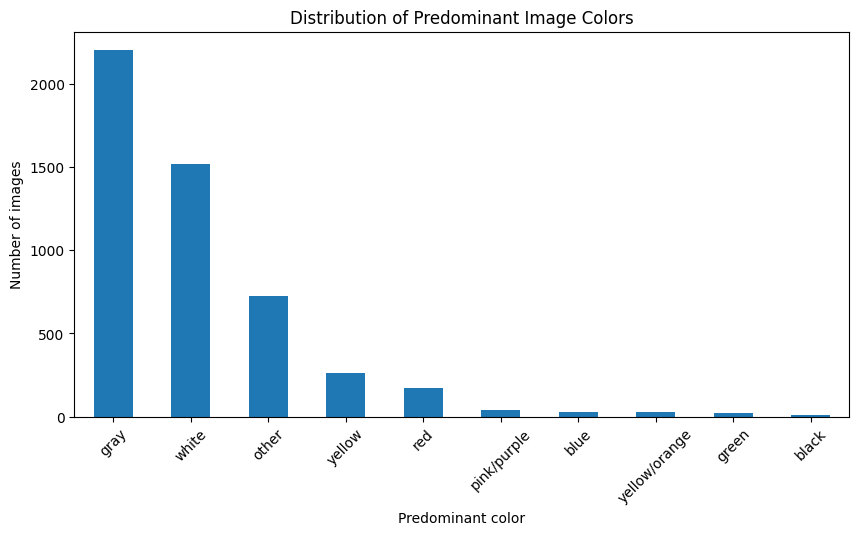

In [16]:
plt.figure(figsize=(10, 5))

color_counts.plot(kind="bar")

plt.xlabel("Predominant color")
plt.ylabel("Number of images")
plt.title("Distribution of Predominant Image Colors")
plt.xticks(rotation=45)

plt.show()

In [17]:
from collections import Counter
import re

text = " ".join(train["title"].fillna("").astype(str))

# Only words made entirely of letters
words = re.findall(r'\b[a-zA-Z]+\b', text.lower())

word_counts = Counter(words)

top20 = word_counts.most_common(20)

print(top20)

[('anak', 2056), ('wanita', 1903), ('original', 1823), ('murah', 1459), ('tas', 1306), ('pria', 1188), ('masker', 1166), ('dan', 1159), ('bayi', 1129), ('ml', 1102), ('anti', 1078), ('untuk', 1077), ('set', 1041), ('baby', 932), ('isi', 880), ('tangan', 869), ('air', 856), ('kaos', 852), ('baju', 840), ('warna', 840)]


In [19]:
from PIL import Image
import numpy as np

def get_color_count(image_path):
    img = Image.open(image_path).convert("RGB")
    img = img.resize((64, 64))

    rgb = np.array(img) / 255.0
    r, g, b = rgb[:,:,0], rgb[:,:,1], rgb[:,:,2]

    # Brightness and saturation
    mx = rgb.max(axis=2)
    mn = rgb.min(axis=2)
    diff = mx - mn

    # Approximate HSV hue
    hue = np.zeros_like(mx)

    mask = diff != 0

    # Red
    idx = (mx == r) & mask
    hue[idx] = ((g[idx] - b[idx]) / diff[idx]) % 6

    # Green
    idx = (mx == g) & mask
    hue[idx] = (b[idx] - r[idx]) / diff[idx] + 2

    # Blue
    idx = (mx == b) & mask
    hue[idx] = (r[idx] - g[idx]) / diff[idx] + 4

    hue /= 6.0

    # Convert hue to degrees
    hue *= 360

    colors_present = set()

    for h, s, v in zip(hue.flatten(), diff.flatten(), mx.flatten()):

        if v < 0.20:
            colors_present.add("black")

        elif v > 0.85 and s < 0.15:
            colors_present.add("white")

        elif s < 0.20:
            colors_present.add("gray")

        elif h < 15 or h >= 345:
            colors_present.add("red")

        elif h < 45:
            colors_present.add("orange")

        elif h < 75:
            colors_present.add("yellow")

        elif h < 165:
            colors_present.add("green")

        elif h < 255:
            colors_present.add("blue")

        elif h < 285:
            colors_present.add("purple")

        else:
            colors_present.add("pink")

    return len(colors_present)

In [20]:
from concurrent.futures import ThreadPoolExecutor
from tqdm import tqdm
import os

with ThreadPoolExecutor(max_workers=8) as executor:
    color_counts = list(tqdm(
        executor.map(
            get_color_count,
            [os.path.join(IMG_DIR, f) for f in sample["image"]]
        ),
        total=len(sample)
    ))

sample["num_colors"] = color_counts

100%|██████████| 5000/5000 [00:35<00:00, 142.28it/s]


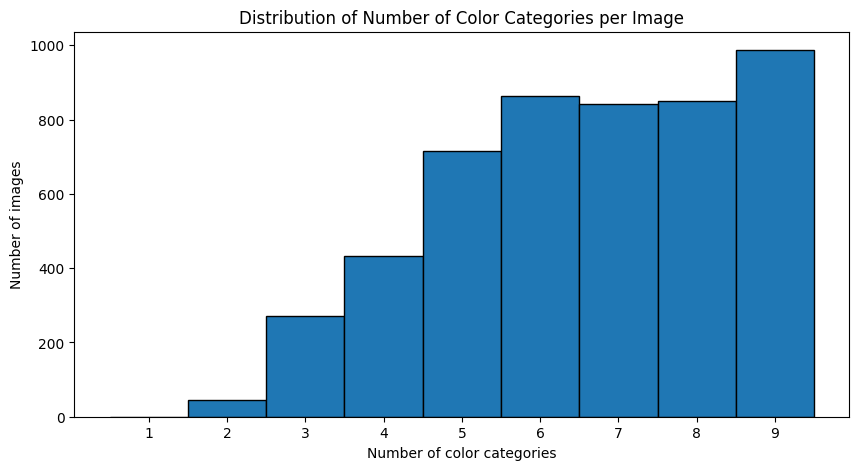

In [22]:
plt.figure(figsize=(10, 5))

plt.hist(
    sample["num_colors"],
    bins=range(1, 11),
    align="left",
    edgecolor="black"
)

plt.xlabel("Number of color categories")
plt.ylabel("Number of images")
plt.title("Distribution of Number of Color Categories per Image")
plt.xticks(range(1, 10))

plt.show()

In [23]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import NearestNeighbors

vectorizer = TfidfVectorizer()

X = vectorizer.fit_transform(
    sample["title"].fillna("")
)

nn = NearestNeighbors(
    n_neighbors=10,
    metric="cosine",
    n_jobs=-1
)

nn.fit(X)

distances, indices = nn.kneighbors(X)

similarities = 1 - distances

Number of matching pairs: 474


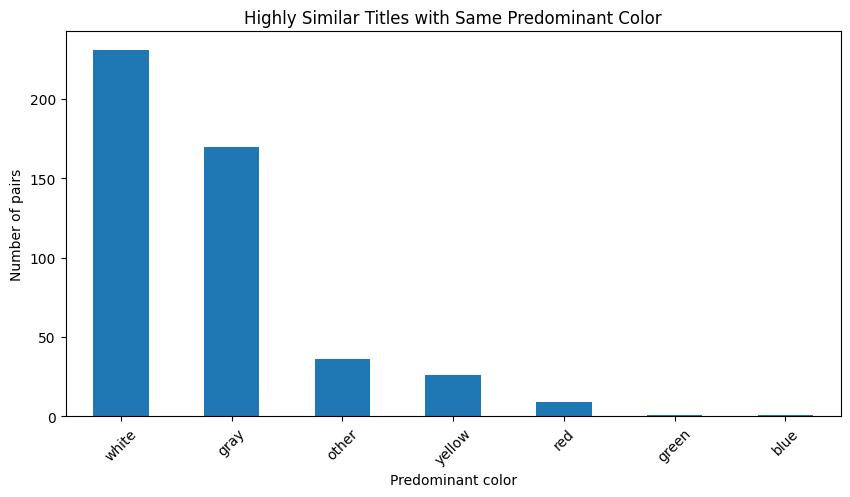

In [24]:
import pandas as pd
import matplotlib.pyplot as plt

pairs = []

for i in range(len(sample)):
    for j, sim in zip(indices[i, 1:], similarities[i, 1:]):

        if sim >= 0.8:
            if sample.iloc[i]["dominant_color"] == sample.iloc[j]["dominant_color"]:

                pairs.append({
                    "image1": sample.iloc[i]["image"],
                    "image2": sample.iloc[j]["image"],
                    "color": sample.iloc[i]["dominant_color"],
                    "similarity": sim
                })

# Create dataframe
similar_pairs = pd.DataFrame(pairs)

print("Number of matching pairs:", len(similar_pairs))

# Plot
color_pair_counts = similar_pairs["color"].value_counts()

plt.figure(figsize=(10, 5))
color_pair_counts.plot(kind="bar")

plt.xlabel("Predominant color")
plt.ylabel("Number of pairs")
plt.title("Highly Similar Titles with Same Predominant Color")
plt.xticks(rotation=45)
plt.show()

### Image - Title Relationship
Products belonging to same label group might have completely different images.
Checking title similarity between same label groups and how many pairs have different label groups but similar titles

In [29]:
same_group = []
different_group = []

for i in range(len(sample)):
    for j, sim in zip(indices[i, 1:], similarities[i, 1:]):

        group_i = sample.iloc[i]["label_group"]
        group_j = sample.iloc[j]["label_group"]

        if group_i == group_j:
            same_group.append(sim)
        else:
            different_group.append(sim)

print("Same-label pairs:", len(same_group))
print("Different-label pairs:", len(different_group))

# Highly similar pairs
threshold = 0.8

same_high = sum(sim >= threshold for sim in same_group)
different_high = sum(sim >= threshold for sim in different_group)

print(f"\nSame-label pairs with similarity >= {threshold}: {same_high}")
print(f"Different-label pairs with similarity >= {threshold}: {different_high}")

Same-label pairs: 2967
Different-label pairs: 42033

Same-label pairs with similarity >= 0.8: 570
Different-label pairs with similarity >= 0.8: 162
